<a href="https://colab.research.google.com/github/sirigiribhargavi-web/ppmcad18/blob/main/week4_agentic_frameworks_orchestration_learner_notebook_executed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 4 Learner Notebook  
## Agentic Frameworks & Orchestration

**Session theme:** Move from “an LLM answers a question” to “an agent manages a job.”  

This notebook is designed for learners to run, modify, and keep after class. It follows the Week 3 session flow:

- **Day 1 — The “Naked” Agent:** Build raw Python versions of routing, tool use, memory, retry logic, and reflection.
- **Day 2 — The Framework Face-Off:** Compare orchestration styles and simulate framework patterns before using full libraries.

> You do **not** need API keys for this notebook. The examples use mock tools and deterministic Python so you can focus on orchestration logic.

## Learning outcomes

By the end of this notebook, you should be able to:

1. Explain why linear chains fail for agentic tasks.
2. Identify the four core parts of a basic agent: **planner, memory, tool registry, executor**.
3. Build a simple router that chooses tools from a registry.
4. Add deterministic control: retries, validation, state, and reflection.
5. Compare orchestration frameworks, MCP, agentic skills/modules, and lifecycle hooks.
6. Estimate the “agent tax” in cost, latency, and debugging complexity.
7. Simulate two common framework styles:
   - **Role/task orchestration** similar to CrewAI-style thinking.
   - **State-machine orchestration** similar to LangGraph-style thinking.

## How to use this notebook

Run the cells from top to bottom.

When you see **Try it**, pause and edit the code or answer in the markdown space.  
When you see **Reference implementation**, try your own version first, then compare.

Recommended pace:

- **Beginner path:** Run all cells and change the example inputs.
- **Intermediate path:** Complete each “Try it” task before reading the reference implementation.
- **Advanced path:** Complete the optional extensions and adapt the examples to your own domain use case.

In [ ]:
# Setup: run this cell first.

import json
import random
import time
from dataclasses import dataclass, field
from typing import Any, Callable, Dict, List, Tuple, Optional

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

pd.set_option("display.max_colwidth", 140)
random.seed(7)

def display_title(text: str):
    print("\n" + "=" * len(text))
    print(text)
    print("=" * len(text))

def draw_box(ax, xy, text, width=2.4, height=0.65, fontsize=10):
    x, y = xy
    box = FancyBboxPatch(
        (x, y),
        width,
        height,
        boxstyle="round,pad=0.03",
        linewidth=1.2,
        facecolor="white",
        edgecolor="black",
    )
    ax.add_patch(box)
    ax.text(x + width / 2, y + height / 2, text, ha="center", va="center", fontsize=fontsize)
    return box

def draw_arrow(ax, start, end):
    arrow = FancyArrowPatch(
        start,
        end,
        arrowstyle="->",
        mutation_scale=12,
        linewidth=1.2,
        color="black",
    )
    ax.add_patch(arrow)
    return arrow

print("Setup complete.")

Setup complete.


# Part 0 — From RAG pipelines to agentic orchestration

In many earlier AI applications, you built a predictable pipeline:

> user question → retrieve context → generate answer → return answer

That is useful, but it is still mostly a **linear chain**.

Agentic systems need more than a chain because real tasks involve uncertainty:

- The tool may fail.
- The model may choose the wrong step.
- The answer may need review.
- The workflow may need to pause for a human.
- The system may need memory across steps.
- The task may require loops, branching, and recovery.

A useful rule:

> **RAG answers a question. Orchestration manages a job.**

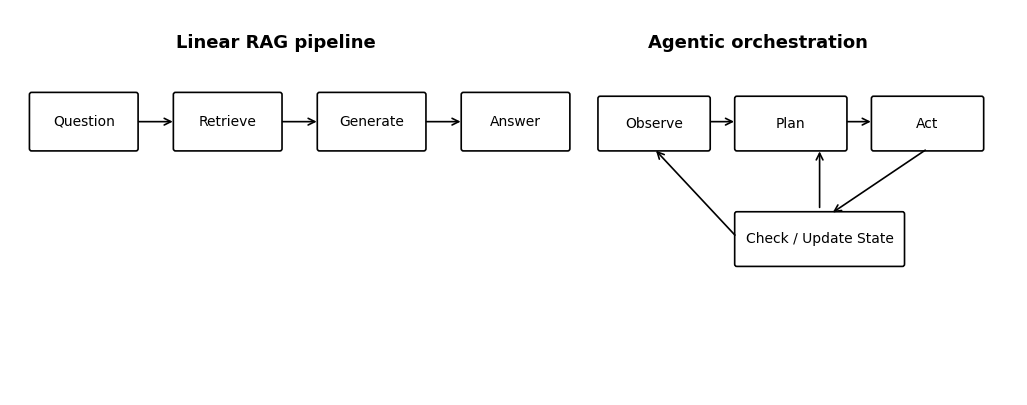

In [ ]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.axis("off")
ax.set_xlim(0, 14)
ax.set_ylim(0, 5)

# RAG pipeline
ax.text(3.7, 4.5, "Linear RAG pipeline", ha="center", fontsize=13, weight="bold")
for i, label in enumerate(["Question", "Retrieve", "Generate", "Answer"]):
    draw_box(ax, (0.3 + i * 2.0, 3.2), label, width=1.45, height=0.7)
    if i < 3:
        draw_arrow(ax, (1.75 + i * 2.0, 3.55), (2.3 + i * 2.0, 3.55))

# Agentic orchestration
ax.text(10.4, 4.5, "Agentic orchestration", ha="center", fontsize=13, weight="bold")
draw_box(ax, (8.2, 3.2), "Observe", width=1.5)
draw_box(ax, (10.1, 3.2), "Plan", width=1.5)
draw_box(ax, (12.0, 3.2), "Act", width=1.5)
draw_box(ax, (10.1, 1.7), "Check / Update State", width=2.3)

draw_arrow(ax, (9.7, 3.55), (10.1, 3.55))
draw_arrow(ax, (11.6, 3.55), (12.0, 3.55))
draw_arrow(ax, (12.75, 3.2), (11.4, 2.35))
draw_arrow(ax, (10.1, 2.05), (8.95, 3.2))
draw_arrow(ax, (11.25, 2.4), (11.25, 3.2))

plt.show()

## The 2026 agentic stack: four layers to keep separate

The vocabulary can get confusing because people use “agent framework” to mean many things. This matrix separates four ideas.

In [ ]:
stack_df = pd.DataFrame({
    "Dimension": [
        "Primary goal",
        "State management",
        "Reasoning",
        "Human-in-the-loop",
        "Privacy/control",
    ],
    "Orchestration frameworks\n(LangGraph, CrewAI)": [
        "Manage who acts, when, and why",
        "High: persistent state machines or task state",
        "Architectural: planning, loops, self-correction",
        "Often native: interrupt, review, resume",
        "Orchestrator-led: you decide where the brain and logs live",
    ],
    "MCP\n(Model Context Protocol)": [
        "Standardize model-to-tool communication",
        "Low: mostly connection/handshake focused",
        "None by itself: it is not the planner",
        "Indirect: tools can request human data",
        "Source-led: useful when tools/data stay local",
    ],
    "Agentic skills\n(modules)": [
        "Package domain logic as reusable capabilities",
        "Medium: may keep local/session memory",
        "Procedural: knows how to handle a task type",
        "Scripted: can include review steps",
        "Manifest-led: permissions defined by module",
    ],
    "Lifecycle hooks\n(event triggers)": [
        "Enforce deterministic rules at key moments",
        "Transient: only during the event",
        "If-then logic: validate, block, transform",
        "Blocking: can pause until approved",
        "Local: often runs near the host system",
    ],
})

stack_df

,Dimension,"Orchestration frameworks\n(LangGraph, CrewAI)",MCP\n(Model Context Protocol),Agentic skills\n(modules),Lifecycle hooks\n(event triggers)
0,Primary goal,"Manage who acts, when, and why",Standardize model-to-tool communication,Package domain logic as reusable capabilities,Enforce deterministic rules at key moments
1,State management,High: persistent state machines or task state,Low: mostly connection/handshake focused,Medium: may keep local/session memory,Transient: only during the event
2,Reasoning,"Architectural: planning, loops, self-correction",None by itself: it is not the planner,Procedural: knows how to handle a task type,"If-then logic: validate, block, transform"
3,Human-in-the-loop,"Often native: interrupt, review, resume",Indirect: tools can request human data,Scripted: can include review steps,Blocking: can pause until approved
4,Privacy/control,Orchestrator-led: you decide where the brain and logs live,Source-led: useful when tools/data stay local,Manifest-led: permissions defined by module,Local: often runs near the host system


### Knowledge check

For each question, write your answer before revealing the suggested answer.

1. Which layer decides the next step in a multi-step job?
2. Which layer standardizes how a model connects to tools?
3. Which layer is best for deterministic safety checks?
4. Which layer packages repeatable domain expertise?

In [ ]:
knowledge_check_answers = {
    "1": "Orchestration framework",
    "2": "MCP",
    "3": "Lifecycle hook / event trigger",
    "4": "Agentic skill / module",
}

print(knowledge_check_answers)

{'1': 'Orchestration framework',
 '2': 'MCP',
 '3': 'Lifecycle hook / event trigger',
 '4': 'Agentic skill / module'}

# Day 1 — The “Naked” Agent

**Goal:** Build agent logic using raw Python first.

Frameworks are easier to understand when you know what they are abstracting away.

## 1. Why linear chains fail

A linear chain assumes every step succeeds and the next step is known in advance.

That breaks when:

- The user asks for multiple actions.
- A tool returns malformed data.
- The model chooses a weak plan.
- A human approval is required.
- Memory from earlier steps changes what should happen next.

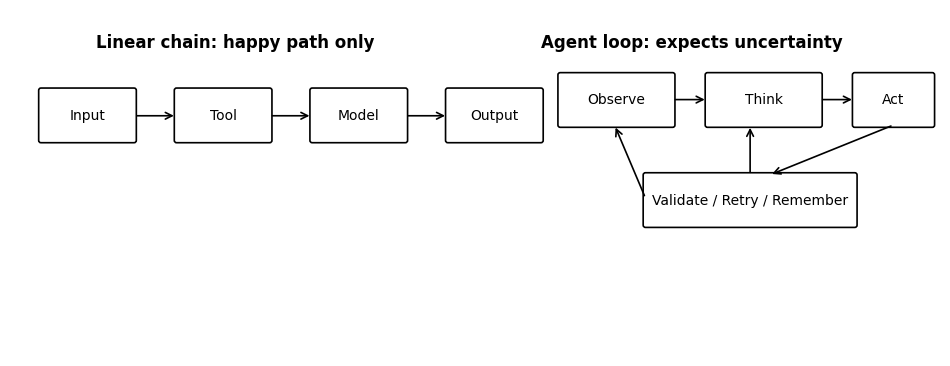

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.axis("off")
ax.set_xlim(0, 12)
ax.set_ylim(0, 4.5)

ax.text(2.9, 4.0, "Linear chain: happy path only", ha="center", fontsize=12, weight="bold")
for i, label in enumerate(["Input", "Tool", "Model", "Output"]):
    draw_box(ax, (0.4 + i * 1.75, 2.8), label, width=1.2, height=0.65)
    if i < 3:
        draw_arrow(ax, (1.6 + i * 1.75, 3.12), (2.15 + i * 1.75, 3.12))

ax.text(8.8, 4.0, "Agent loop: expects uncertainty", ha="center", fontsize=12, weight="bold")
draw_box(ax, (7.1, 3.0), "Observe", width=1.45)
draw_box(ax, (9.0, 3.0), "Think", width=1.45)
draw_box(ax, (10.9, 3.0), "Act", width=1.0)
draw_box(ax, (8.2, 1.7), "Validate / Retry / Remember", width=2.7)

draw_arrow(ax, (8.55, 3.33), (9.0, 3.33))
draw_arrow(ax, (10.45, 3.33), (10.9, 3.33))
draw_arrow(ax, (11.4, 3.0), (9.8, 2.35))
draw_arrow(ax, (8.2, 2.05), (7.8, 3.0))
draw_arrow(ax, (9.55, 2.35), (9.55, 3.0))

plt.show()

## 2. Debugging diagnostic: “What broke?”

Agent systems usually fail in one of three ways:

| Failure type | What it means | Example |
|---|---|---|
| Logic/planning failure | The agent chose the wrong next step | It emailed a customer before checking policy |
| Tool/API failure | The tool did not work or returned bad data | The travel API returned invalid JSON |
| Data/context failure | The information given to the model was incomplete or stale | The policy document was outdated |

### Try it

Read the three logs below and classify each as:

- `logic`
- `tool`
- `data`

In [ ]:
logs = [
    {
        "id": "A",
        "trace": [
            "User asks: Can I refund a premium support plan after 45 days?",
            "Agent action: send_email",
            "Email says: Your refund is approved.",
            "Note: policy_search was never called.",
        ],
    },
    {
        "id": "B",
        "trace": [
            "Agent action: search_flights",
            "Tool response: {price: 720, currency: USD",
            "Parser error: Expecting property name enclosed in double quotes",
        ],
    },
    {
        "id": "C",
        "trace": [
            "Agent action: policy_search",
            "Retrieved policy: Refunds allowed within 30 days.",
            "Hidden fact: Premium support contract updated yesterday to allow 60 days.",
        ],
    },
]

for item in logs:
    print(f"\nLog {item['id']}")
    for line in item["trace"]:
        print(" -", line)


Log A
 - User asks: Can I refund a premium support plan after 45 days?
 - Agent action: send_email
 - Email says: Your refund is approved.
 - Note: policy_search was never called.

Log B
 - Agent action: search_flights
 - Tool response: {price: 720, currency: USD
 - Parser error: Expecting property name enclosed in double quotes

Log C
 - Agent action: policy_search
 - Retrieved policy: Refunds allowed within 30 days.
 - Hidden fact: Premium support contract updated yesterday to allow 60 days.


In [ ]:
# Suggested answers. Try classifying first, then run this cell.

diagnostic_answers = {
    "A": "logic/planning failure",
    "B": "tool/API failure",
    "C": "data/context failure",
}

diagnostic_answers

{'A': 'logic/planning failure',
 'B': 'tool/API failure',
 'C': 'data/context failure'}

## 3. The four pillars of a minimal agent

A basic agent needs four parts.

In [ ]:
pillars = pd.DataFrame([
    {
        "Pillar": "Planner",
        "Plain-English role": "Decides the next step",
        "Raw Python version": "A function that selects a tool",
        "Framework version": "Router node, role policy, graph edge",
    },
    {
        "Pillar": "Short-term memory",
        "Plain-English role": "Tracks what has happened so far",
        "Raw Python version": "A dictionary or state object",
        "Framework version": "State object, run context, task memory",
    },
    {
        "Pillar": "Tool registry",
        "Plain-English role": "Lists actions the agent can take",
        "Raw Python version": "Dictionary of tool names to functions",
        "Framework version": "Tools, connectors, MCP servers",
    },
    {
        "Pillar": "Executor",
        "Plain-English role": "Runs the chosen action and stores result",
        "Raw Python version": "Function call + error handling",
        "Framework version": "Runtime, agent loop, graph runner",
    },
])

pillars

,Pillar,Plain-English role,Raw Python version,Framework version
0,Planner,Decides the next step,A function that selects a tool,"Router node, role policy, graph edge"
1,Short-term memory,Tracks what has happened so far,A dictionary or state object,"State object, run context, task memory"
2,Tool registry,Lists actions the agent can take,Dictionary of tool names to functions,"Tools, connectors, MCP servers"
3,Executor,Runs the chosen action and stores result,Function call + error handling,"Runtime, agent loop, graph runner"


## 4. Exercise: retry loop around an unreliable tool

Some tools return malformed or incomplete output. Your agent should not blindly pass that output forward.

Here is a mock API tool that sometimes returns malformed JSON.

In [ ]:
def unreliable_json_tool() -> str:
    """Return valid JSON sometimes and malformed JSON sometimes."""
    outputs = [
        '{"status": "ok", "price": 720, "currency": "USD"}',
        '{status: ok, price: 720, currency: USD}',       # malformed
        '{"status": "ok", "price": "720", "currency": "USD"}',
        '{"status": "ok", "price": 690, "currency": "USD"}',
        '{"status": "ok", "price": 740, "currency": "USD"',  # malformed
    ]
    return random.choice(outputs)

for _ in range(5):
    print(unreliable_json_tool())

{"status": "ok", "price": "720", "currency": "USD"}
{status: ok, price: 720, currency: USD}
{"status": "ok", "price": 690, "currency": "USD"}
{"status": "ok", "price": 720, "currency": "USD"}
{"status": "ok", "price": 720, "currency": "USD"}


### Try it

Design pseudocode for a retry loop:

1. Call the tool.
2. Try to parse the JSON.
3. Validate that `price` is a number and `currency` is present.
4. If it fails, retry up to 3 times.
5. If all retries fail, escalate to a human or return a safe failure message.

Write your pseudocode here:

```text
YOUR PSEUDOCODE:
1.
2.
3.
```

In [ ]:
def validate_price_payload(payload: Dict[str, Any]) -> Tuple[bool, str]:
    """Return (is_valid, reason)."""
    if "price" not in payload:
        return False, "missing price"
    if not isinstance(payload["price"], (int, float)):
        return False, "price is not numeric"
    if "currency" not in payload:
        return False, "missing currency"
    return True, "valid"

def call_with_retry(max_attempts: int = 3) -> Dict[str, Any]:
    """
    Reference implementation.
    Deterministic orchestration controls the uncertainty of the tool.
    """
    attempts = []

    for attempt in range(1, max_attempts + 1):
        raw = unreliable_json_tool()
        record = {"attempt": attempt, "raw": raw}

        try:
            parsed = json.loads(raw)
            is_valid, reason = validate_price_payload(parsed)
            record["parsed"] = parsed
            record["valid"] = is_valid
            record["reason"] = reason
            attempts.append(record)

            if is_valid:
                return {
                    "status": "success",
                    "result": parsed,
                    "attempts": attempts,
                }

        except json.JSONDecodeError as exc:
            record["valid"] = False
            record["reason"] = f"JSON decode error: {exc.msg}"
            attempts.append(record)

    return {
        "status": "needs_human_review",
        "result": None,
        "attempts": attempts,
    }

result = call_with_retry(max_attempts=3)
result

{'status': 'success',
 'result': {'status': 'ok', 'price': 720, 'currency': 'USD'},
 'attempts': [{'attempt': 1,
   'raw': '{"status": "ok", "price": 740, "currency": "USD"',
   'valid': False,
   'reason': "JSON decode error: Expecting ',' delimiter"},
  {'attempt': 2,
   'raw': '{"status": "ok", "price": 720, "currency": "USD"}',
   'parsed': {'status': 'ok', 'price': 720, 'currency': 'USD'},
   'valid': True,
   'reason': 'valid'}]}

In [ ]:
# Run the retry logic several times to see different outcomes.
for run in range(1, 6):
    result = call_with_retry(max_attempts=3)
    print(f"Run {run}: {result['status']}")
    for attempt in result["attempts"]:
        print("  ", attempt["attempt"], "-", attempt["reason"])
    print()

Run 1: success
   1 - price is not numeric
   2 - JSON decode error: Expecting ',' delimiter
   3 - valid

Run 2: success
   1 - JSON decode error: Expecting ',' delimiter
   2 - JSON decode error: Expecting property name enclosed in double quotes
   3 - valid

Run 3: success
   1 - valid

Run 4: success
   1 - valid

Run 5: success
   1 - valid



### What this teaches

The model/tool ecosystem may be probabilistic or unreliable, but the surrounding orchestration should be deterministic where possible.

Deterministic controls include:

- Retry count
- Validation rules
- Stop conditions
- Escalation rules
- Logging/tracing

## 5. Build a “naked” router

A router is the simplest form of planning.

It answers:

> Given the user goal and current state, which tool should run next?

In [ ]:
# Tool functions

def search_policy(query: str) -> str:
    return (
        f"POLICY_RESULT for '{query}': "
        "Refunds are allowed within 30 days. Premium support exceptions may apply."
    )

def retrieve_from_vector_db(query: str) -> str:
    return (
        f"RETRIEVED_CHUNKS for '{query}': "
        "Chunk 12 mentions refund windows. Chunk 19 mentions premium exceptions."
    )

def send_email(draft: str) -> str:
    return f"EMAIL_DRAFT_CREATED: {draft[:100]}..."

def calculate_cost(tokens: int) -> str:
    # Example placeholder math. Replace with current provider pricing for real planning.
    cost_per_1k_tokens = 0.002
    return f"Estimated cost for {tokens} tokens: ${tokens / 1000 * cost_per_1k_tokens:.4f}"

tool_registry: Dict[str, Callable[..., str]] = {
    "search_policy": search_policy,
    "retrieve_from_vector_db": retrieve_from_vector_db,
    "send_email": send_email,
    "calculate_cost": calculate_cost,
}

list(tool_registry.keys())

['search_policy', 'retrieve_from_vector_db', 'send_email', 'calculate_cost']

In [ ]:
def simple_router(user_goal: str) -> str:
    """
    A deliberately simple router.
    It uses keywords instead of an LLM so you can see the orchestration pattern clearly.
    """
    text = user_goal.lower()

    if "policy" in text or "refund" in text or "allowed" in text:
        return "search_policy"

    if "retrieve" in text or "chunks" in text or "document" in text:
        return "retrieve_from_vector_db"

    if "email" in text or "reply" in text or "send" in text:
        return "send_email"

    if "cost" in text or "tokens" in text:
        return "calculate_cost"

    return "search_policy"  # safe default for this demo

def execute_single_step(user_goal: str) -> Dict[str, Any]:
    selected_tool = simple_router(user_goal)

    if selected_tool == "calculate_cost":
        output = tool_registry[selected_tool](tokens=2500)
    else:
        output = tool_registry[selected_tool](user_goal)

    return {
        "goal": user_goal,
        "selected_tool": selected_tool,
        "output": output,
    }

examples = [
    "Can the customer get a refund after 45 days?",
    "Retrieve the policy document chunks about premium support.",
    "Draft an email reply to the customer.",
    "Estimate the cost for this 2500-token request.",
    ""
]

for example in examples:
    print(execute_single_step(example), "\n")

{'goal': 'Can the customer get a refund after 45 days?', 'selected_tool': 'search_policy', 'output': "POLICY_RESULT for 'Can the customer get a refund after 45 days?': Refunds are allowed within 30 days. Premium support exceptions may apply."} 

{'goal': 'Retrieve the policy document chunks about premium support.', 'selected_tool': 'search_policy', 'output': "POLICY_RESULT for 'Retrieve the policy document chunks about premium support.': Refunds are allowed within 30 days. Premium support exceptions may apply."} 

{'goal': 'Draft an email reply to the customer.', 'selected_tool': 'send_email', 'output': 'EMAIL_DRAFT_CREATED: Draft an email reply to the customer....'} 

{'goal': 'Estimate the cost for this 2500-token request.', 'selected_tool': 'calculate_cost', 'output': 'Estimated cost for 2500 tokens: $0.0050'} 



### Try it

Add one more tool to the registry.

Ideas:

- `summarize_ticket`
- `classify_urgency`
- `lookup_customer_tier`
- `create_todo`

Then update `simple_router()` so it can select your new tool.

In [ ]:
# Reference implementation: add a new tool.

def classify_urgency(ticket_text: str) -> str:
    text = ticket_text.lower()
    if any(word in text for word in ["down", "urgent", "blocked", "critical"]):
        return "URGENCY: high"
    if any(word in text for word in ["soon", "delayed", "issue"]):
        return "URGENCY: medium"
    return "URGENCY: low"

tool_registry["classify_urgency"] = classify_urgency

def router_with_urgency(user_goal: str) -> str:
    text = user_goal.lower()

    if "urgent" in text or "critical" in text or "blocked" in text or "urgency" in text:
        return "classify_urgency"

    return simple_router(user_goal)

def execute_with_urgency(user_goal: str) -> Dict[str, Any]:
    selected_tool = router_with_urgency(user_goal)

    if selected_tool == "calculate_cost":
        output = tool_registry[selected_tool](tokens=2500)
    else:
        output = tool_registry[selected_tool](user_goal)

    return {
        "goal": user_goal,
        "selected_tool": selected_tool,
        "output": output,
    }

execute_with_urgency("Customer says their production system is down and they are blocked.")

{'goal': 'Customer says their production system is down and they are blocked.',
 'selected_tool': 'classify_urgency',
 'output': 'URGENCY: high'}

## 6. Add state: remembering across steps

A stateless agent starts fresh at each step.  
A stateful agent carries forward what happened before.

In raw Python, a state object can be as simple as a dictionary.

In [ ]:
state = {
    "user_name": None,
    "last_tool": None,
    "messages": [],
    "facts": {},
}

def update_state_from_message(state: Dict[str, Any], message: str) -> Dict[str, Any]:
    """Very small example of state extraction."""
    state["messages"].append(message)

    lower = message.lower()
    if "my name is" in lower:
        name = message.split("my name is", 1)[-1].strip().strip(".")
        state["user_name"] = name.title()

    if "premium customer" in lower:
        state["facts"]["customer_tier"] = "premium"

    return state

def respond_with_state(state: Dict[str, Any], message: str) -> str:
    state = update_state_from_message(state, message)

    if "what is my name" in message.lower():
        return f"Your name is {state['user_name']}." if state["user_name"] else "I do not know your name yet."

    if "tier" in message.lower():
        return f"Known customer tier: {state['facts'].get('customer_tier', 'unknown')}."

    return "State updated."

print(respond_with_state(state, "My name is Asha."))
print(respond_with_state(state, "This is a premium customer."))
print(respond_with_state(state, "What is my name?"))
print(respond_with_state(state, "What tier is the customer?"))
state

State updated.
State updated.
Your name is My Name Is Asha.
Known customer tier: premium.


{'user_name': 'My Name Is Asha',
 'last_tool': None,
 'messages': ['My name is Asha.',
  'This is a premium customer.',
  'What is my name?',
  'What tier is the customer?'],
 'facts': {'customer_tier': 'premium'}}

### Try it

Extend the state dictionary so it also remembers:

- The last customer issue.
- Whether the issue has been resolved.
- The number of tool calls made so far.

This is the core idea behind state objects in orchestration frameworks.

In [ ]:
# Reference implementation: richer state.

state_v2 = {
    "user_name": None,
    "last_tool": None,
    "messages": [],
    "facts": {},
    "last_customer_issue": None,
    "resolved": False,
    "tool_call_count": 0,
}

def update_state_v2(state: Dict[str, Any], message: str, tool_name: Optional[str] = None) -> Dict[str, Any]:
    state["messages"].append(message)

    if tool_name:
        state["last_tool"] = tool_name
        state["tool_call_count"] += 1

    lower = message.lower()

    if "issue:" in lower:
        state["last_customer_issue"] = message.split("issue:", 1)[-1].strip()

    if "resolved" in lower or "fixed" in lower:
        state["resolved"] = True

    return state

state_v2 = update_state_v2(state_v2, "Issue: customer cannot access invoice portal", tool_name="classify_urgency")
state_v2 = update_state_v2(state_v2, "The issue is resolved.", tool_name="send_email")

state_v2

{'user_name': None,
 'last_tool': 'send_email',
 'messages': ['Issue: customer cannot access invoice portal',
  'The issue is resolved.'],
 'facts': {},
 'last_customer_issue': 'Issue: customer cannot access invoice portal',
 'resolved': True,
 'tool_call_count': 2}

## 7. Reflection step: make the agent review its own output

A reflection step is a quality gate.

It asks:

- Did we answer the user’s question?
- Did we use the right tool?
- Is the output safe to send?
- Should we retry, revise, or escalate?

In [ ]:
def draft_customer_reply(context: str, question: str) -> str:
    """Mock drafting function."""
    return (
        "Dear customer, based on the policy, refunds are usually available within 30 days. "
        "Premium support exceptions may apply, so I will escalate this for review."
    )

def reflect_on_reply(reply: str, required_terms: List[str]) -> Dict[str, Any]:
    missing_terms = [term for term in required_terms if term.lower() not in reply.lower()]
    score = max(0, 1 - len(missing_terms) / max(len(required_terms), 1))

    if missing_terms:
        recommendation = "revise"
    else:
        recommendation = "send"

    return {
        "score": round(score, 2),
        "missing_terms": missing_terms,
        "recommendation": recommendation,
    }

reply = draft_customer_reply(
    context="Refund policy and premium support exception rules.",
    question="Can the customer get a refund after 45 days?"
)

reflection = reflect_on_reply(reply, required_terms=["30 days", "premium", "escalate"])

print(reply)
reflection

Dear customer, based on the policy, refunds are usually available within 30 days. Premium support exceptions may apply, so I will escalate this for review.


{'score': 1.0, 'missing_terms': [], 'recommendation': 'send'}

### Advanced extension

Modify `reflect_on_reply()` so that it checks for:

- Unsupported promises, such as “guaranteed refund.”
- Missing next action.
- Tone problems.
- Private/sensitive information that should not be sent.

## Day 1 Segment 9 — 01:35–01:45  
# The “Bare-Bones” Wall: When Manual Code Becomes Unmanageable



## Detailed explanation

Manual orchestration becomes hard when you need:

- Multiple tools.
- Multiple agents.
- Conditional routing.
- Loops with stop conditions.
- Long-running state.
- Human approval.
- Streaming results.
- Logging and tracing.
- Cost and latency tracking.
- Error recovery.
- Deployment and access control.

##

“Writing one retry loop is fine. Writing retries, state, routing, approvals, traces, and rollback logic for every project is not fine. Frameworks emerge when the same pain appears repeatedly.”

---

simple iceberg:

- Above water: “LLM response”
- Below water: “state, tools, retries, validation, tracing, approvals, costs, permissions”

## Question

> “Which part of day 1’s manual code would you least want to maintain across 20 production workflows?”




# Day 2 — The Framework Face-Off

**Goal:** Compare orchestration styles and understand the trade-offs before adopting a full framework.

## Another Example  — Tokyo Travel Request

**Scenario:**  
A user asks:

> “Plan a 5-day Tokyo trip next month. I want cheap hotels, Michelin restaurants, quiet neighborhoods, nightlife, no walking more than 10 minutes, and a total budget under $700 including flights.”

## Why this is a good agentic example

The requirements are contradictory:

- Michelin restaurants conflict with low budget.
- Quiet neighborhoods may conflict with nightlife.
- No walking more than 10 minutes affects hotel and itinerary choices.
- Flights alone may exceed total budget.

## How a naked agent should handle it

1. Extract constraints.
2. Detect contradictions.
3. Ask clarification or propose trade-offs.
4. Search flight/hotel tools.
5. Build draft plan.
6. Validate against budget and walking constraints.
7. Escalate impossible constraints.

## Question

> “Which step should happen before calling any travel API?”



## Misconception

**Misconception:** “The agent should just start searching.”  
**Correction:** Searching before clarifying constraints wastes cost and may produce a plausible but impossible plan.

# Assessment Items

## Question 1

**Prompt:** What is the difference between a vector database and workflow state?


## Question 2

**Prompt:** Why can a simple RAG chatbot be insufficient for an agentic task?











**Model answer1:**  
A vector database stores retrievable knowledge chunks for semantic search. Workflow state stores the progress, decisions, tool results, retries, and status of an active job.




**Model answer2:**  
A simple RAG chatbot usually retrieves context and answers once. Agentic tasks may require deciding next actions, calling tools, validating outputs, retrying failures, pausing for human review, and maintaining state across steps.


## 8. The framework landscape

For Week 3, keep this mental model:

| Framework style | Best for | Watch out for |
|---|---|---|
| State-machine orchestration | Regulated workflows, auditability, deterministic checkpoints | More design work up front |
| Role/task orchestration | Research teams, creative workflows, delegated collaboration | Can become harder to debug |
| Lightweight agent SDKs | Fast prototypes, simple tool-calling agents | May need more custom control later |

The real decision is not “which framework is coolest?”  
The real decision is:

> What kind of control does this workflow need?

In [ ]:
frameworks = pd.DataFrame([
    {
        "Option": "LangGraph-style state graph",
        "Core idea": "Nodes + edges + explicit state",
        "Good fit": "Approval flows, compliance, retries, production workflows",
        "Risk": "Requires workflow design discipline",
    },
    {
        "Option": "CrewAI-style role/task crew",
        "Core idea": "Agents with roles collaborate on tasks",
        "Good fit": "Research, writing, analysis, brainstorming, delegation",
        "Risk": "Role chatter and ambiguous ownership",
    },
    {
        "Option": "Lightweight SDK / custom loop",
        "Core idea": "Direct tool calls and small orchestration loop",
        "Good fit": "Small apps, demos, controlled internal tools",
        "Risk": "Can become messy as tasks branch",
    },
    {
        "Option": "No-code/low-code automation",
        "Core idea": "Visual workflow with connectors",
        "Good fit": "Business process automation and quick integration",
        "Risk": "Complex loops and versioning can be painful",
    },
])

frameworks

,Option,Core idea,Good fit,Risk
0,LangGraph-style state graph,Nodes + edges + explicit state,"Approval flows, compliance, retries, production workflows",Requires workflow design discipline
1,CrewAI-style role/task crew,Agents with roles collaborate on tasks,"Research, writing, analysis, brainstorming, delegation",Role chatter and ambiguous ownership
2,Lightweight SDK / custom loop,Direct tool calls and small orchestration loop,"Small apps, demos, controlled internal tools",Can become messy as tasks branch
3,No-code/low-code automation,Visual workflow with connectors,Business process automation and quick integration,Complex loops and versioning can be painful


## 9. Scenario-based framework selection

For each scenario, choose the best orchestration style and explain why.

1. **Healthcare prior authorization:** must pause for human approval and preserve an audit trail.
2. **Creative campaign ideation:** three specialist agents brainstorm, critique, and refine ideas.
3. **Internal document assistant:** answers questions from one uploaded document and emails the response.
4. **Server incident triage:** checks logs, classifies severity, pages on-call only when needed.

In [ ]:
def recommend_orchestration(scenario: str) -> str:
    text = scenario.lower()

    if any(word in text for word in ["approval", "audit", "regulated", "compliance", "healthcare"]):
        return "State-machine graph: explicit state, checkpoints, and human-in-the-loop."

    if any(word in text for word in ["creative", "brainstorm", "campaign", "specialist", "critique"]):
        return "Role/task crew: multiple agents can contribute from different perspectives."

    if any(word in text for word in ["single document", "uploaded document", "email", "simple"]):
        return "Lightweight SDK or no-code workflow: keep it simple until branching grows."

    if any(word in text for word in ["server", "logs", "incident", "severity", "on-call"]):
        return "State-machine graph with lifecycle hooks: deterministic checks before paging."

    return "Start lightweight, then move to a graph if loops, state, or approvals become important."

scenarios = [
    "Healthcare prior authorization with human approval and audit trail",
    "Creative campaign ideation with specialist agents",
    "Internal assistant answers questions from a single uploaded document and emails the result",
    "Server incident triage from logs with on-call paging",
]

for s in scenarios:
    print(s)
    print(" ->", recommend_orchestration(s), "\n")

Healthcare prior authorization with human approval and audit trail
 -> State-machine graph: explicit state, checkpoints, and human-in-the-loop. 

Creative campaign ideation with specialist agents
 -> Role/task crew: multiple agents can contribute from different perspectives. 

Internal assistant answers questions from a single uploaded document and emails the result
 -> Lightweight SDK or no-code workflow: keep it simple until branching grows. 

Server incident triage from logs with on-call paging
 -> State-machine graph with lifecycle hooks: deterministic checks before paging. 



## 10. Deterministic graphs vs stochastic roles

A useful distinction:

- **Deterministic graph:** You define the allowed path. The model may fill in content, but the workflow controls the route.
- **Stochastic roles:** You define goals and responsibilities. Agents may interact more flexibly, which can be powerful but less predictable.

Neither is universally better. Choose based on risk, audit needs, and task ambiguity.

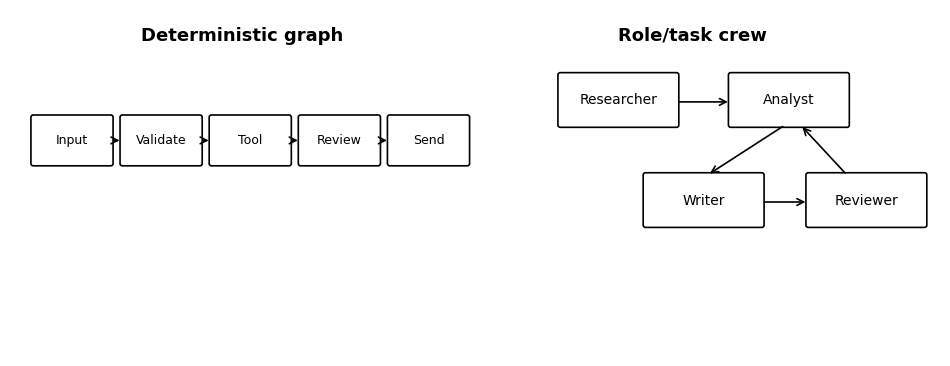

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.axis("off")
ax.set_xlim(0, 12)
ax.set_ylim(0, 4.5)

ax.text(3, 4.1, "Deterministic graph", ha="center", fontsize=13, weight="bold")
for i, label in enumerate(["Input", "Validate", "Tool", "Review", "Send"]):
    draw_box(ax, (0.3 + i * 1.15, 2.5), label, width=1.0, height=0.6, fontsize=9)
    if i < 4:
        draw_arrow(ax, (1.3 + i * 1.15, 2.8), (1.45 + i * 1.15, 2.8))

ax.text(8.8, 4.1, "Role/task crew", ha="center", fontsize=13, weight="bold")
draw_box(ax, (7.1, 3.0), "Researcher", width=1.5)
draw_box(ax, (9.3, 3.0), "Analyst", width=1.5)
draw_box(ax, (8.2, 1.7), "Writer", width=1.5)
draw_box(ax, (10.3, 1.7), "Reviewer", width=1.5)

draw_arrow(ax, (8.6, 3.3), (9.3, 3.3))
draw_arrow(ax, (10.0, 3.0), (9.0, 2.35))
draw_arrow(ax, (9.7, 2.0), (10.3, 2.0))
draw_arrow(ax, (10.8, 2.35), (10.2, 3.0))

plt.show()

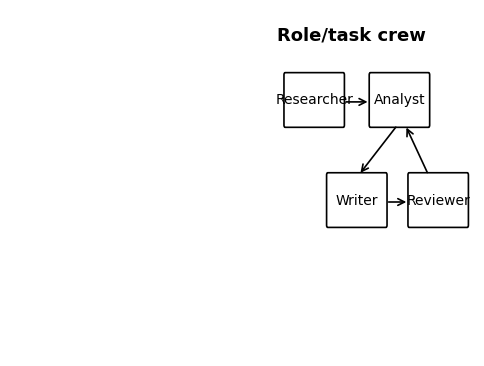

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.axis("off")
ax.set_xlim(0, 12)
ax.set_ylim(0, 4.5)

ax.text(8.8, 4.1, "Role/task crew", ha="center", fontsize=13, weight="bold")
draw_box(ax, (7.1, 3.0), "Researcher", width=1.5)
draw_box(ax, (9.3, 3.0), "Analyst", width=1.5)
draw_box(ax, (8.2, 1.7), "Writer", width=1.5)
draw_box(ax, (10.3, 1.7), "Reviewer", width=1.5)

draw_arrow(ax, (8.6, 3.3), (9.3, 3.3))
draw_arrow(ax, (10.0, 3.0), (9.0, 2.35))
draw_arrow(ax, (9.7, 2.0), (10.3, 2.0))
draw_arrow(ax, (10.8, 2.35), (10.2, 3.0))

plt.show()

## 11. Calculate the “agent tax”

Agentic systems cost more than a single prompt because they often involve:

- More model calls.
- More tool calls.
- More validation.
- More retries.
- More logging and debugging.

This is not bad; it is the price of autonomy and robustness. But you should estimate it.

In [ ]:
def agent_tax_calculator(
    input_tokens_per_call: int,
    output_tokens_per_call: int,
    model_calls: int,
    tool_calls: int,
    retry_rate: float,
    input_cost_per_1k: float,
    output_cost_per_1k: float,
    avg_model_latency_sec: float,
    avg_tool_latency_sec: float,
) -> Dict[str, float]:
    """
    Simple planning calculator.
    Replace the cost inputs with the current pricing for your chosen model/provider.
    """
    expected_model_calls = model_calls * (1 + retry_rate)

    input_cost = (input_tokens_per_call * expected_model_calls / 1000) * input_cost_per_1k
    output_cost = (output_tokens_per_call * expected_model_calls / 1000) * output_cost_per_1k
    total_cost = input_cost + output_cost

    total_latency = (
        expected_model_calls * avg_model_latency_sec
        + tool_calls * avg_tool_latency_sec
    )

    return {
        "expected_model_calls": round(expected_model_calls, 2),
        "estimated_cost_usd": round(total_cost, 4),
        "estimated_latency_sec": round(total_latency, 2),
    }

# Example placeholder values. Replace with current provider pricing in real projects.
agent_tax_calculator(
    input_tokens_per_call=2000,
    output_tokens_per_call=500,
    model_calls=4,
    tool_calls=3,
    retry_rate=0.25,
    input_cost_per_1k=0.003,
    output_cost_per_1k=0.012,
    avg_model_latency_sec=2.0,
    avg_tool_latency_sec=0.8,
)

{'expected_model_calls': 5.0,
 'estimated_cost_usd': 0.06,
 'estimated_latency_sec': 12.4}

### Try it

Change the calculator inputs to compare:

1. A **single-shot prompt**.
2. A **four-step agent**.
3. A **four-step agent with 30% retries**.

What increases faster: cost or latency?

In [ ]:
comparison = pd.DataFrame([
    {
        "Scenario": "Single-shot prompt",
        **agent_tax_calculator(
            input_tokens_per_call=2000,
            output_tokens_per_call=500,
            model_calls=1,
            tool_calls=0,
            retry_rate=0.0,
            input_cost_per_1k=0.003,
            output_cost_per_1k=0.012,
            avg_model_latency_sec=2.0,
            avg_tool_latency_sec=0.8,
        ),
    },
    {
        "Scenario": "Four-step agent",
        **agent_tax_calculator(
            input_tokens_per_call=2000,
            output_tokens_per_call=500,
            model_calls=4,
            tool_calls=3,
            retry_rate=0.0,
            input_cost_per_1k=0.003,
            output_cost_per_1k=0.012,
            avg_model_latency_sec=2.0,
            avg_tool_latency_sec=0.8,
        ),
    },
    {
        "Scenario": "Four-step agent + 30% retries",
        **agent_tax_calculator(
            input_tokens_per_call=2000,
            output_tokens_per_call=500,
            model_calls=4,
            tool_calls=3,
            retry_rate=0.30,
            input_cost_per_1k=0.003,
            output_cost_per_1k=0.012,
            avg_model_latency_sec=2.0,
            avg_tool_latency_sec=0.8,
        ),
    },
])

comparison

,Scenario,expected_model_calls,estimated_cost_usd,estimated_latency_sec
0,Single-shot prompt,1.0,0.0120,2.0
1,Four-step agent,4.0,0.0480,10.4
2,Four-step agent + 30% retries,5.2,0.0624,12.8


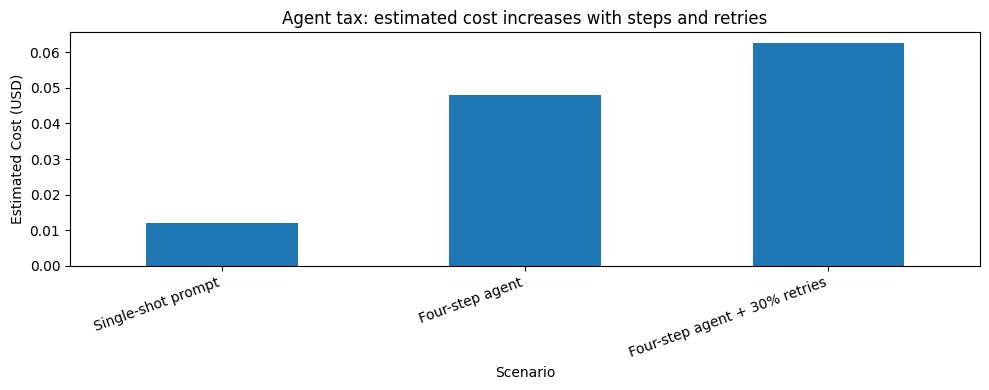

In [ ]:
ax = comparison.plot(
    x="Scenario",
    y=["estimated_cost_usd"],
    kind="bar",
    figsize=(10, 4),
    legend=False
)
ax.set_title("Agent tax: estimated cost increases with steps and retries")
ax.set_ylabel("Estimated Cost (USD)")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

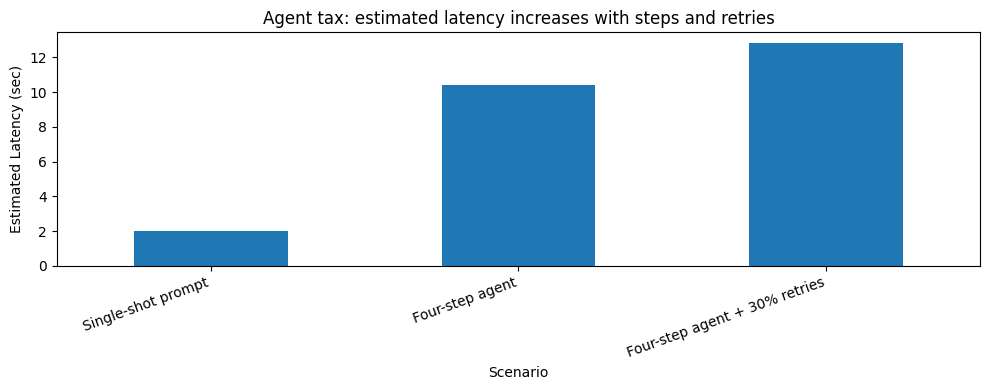

In [ ]:
ax = comparison.plot(
    x="Scenario",
    y=["estimated_latency_sec"],
    kind="bar",
    figsize=(10, 4),
    legend=False
)
ax.set_title("Agent tax: estimated latency increases with steps and retries")
ax.set_ylabel("Estimated Latency (sec)")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

## 12. CrewAI-style simulation: role/task orchestration

This section does **not** import CrewAI. It simulates the mental model:

- Define agents with roles.
- Assign tasks.
- Pass intermediate outputs between them.
- Produce a final artifact.

This lets you understand the pattern before using a framework.

In [ ]:
@dataclass
class RoleAgent:
    name: str
    role: str
    goal: str

    def run(self, task: str, context: str = "") -> str:
        return (
            f"[{self.name} / {self.role}]\n"
            f"Goal: {self.goal}\n"
            f"Task: {task}\n"
            f"Context used: {context[:120] if context else 'None'}\n"
            f"Output: {self._mock_output(task)}"
        )

    def _mock_output(self, task: str) -> str:
        task_lower = task.lower()
        if "research" in task_lower:
            return "Found 3 relevant facts and 2 risks."
        if "analyze" in task_lower:
            return "Prioritized the facts by customer impact and uncertainty."
        if "write" in task_lower:
            return "Drafted a concise recommendation with next steps."
        if "review" in task_lower:
            return "Checked for missing evidence and unsafe claims."
        return "Completed task."

researcher = RoleAgent(
    name="Riya",
    role="Researcher",
    goal="Collect relevant facts without overclaiming."
)

analyst = RoleAgent(
    name="Kabir",
    role="Analyst",
    goal="Turn facts into decision-ready insights."
)

writer = RoleAgent(
    name="Meera",
    role="Writer",
    goal="Create a clear final response for a human stakeholder."
)

reviewer = RoleAgent(
    name="Arjun",
    role="Reviewer",
    goal="Check quality, risks, and missing evidence."
)

crew = [researcher, analyst, writer, reviewer]
crew

[RoleAgent(name='Riya', role='Researcher', goal='Collect relevant facts without overclaiming.'),
 RoleAgent(name='Kabir', role='Analyst', goal='Turn facts into decision-ready insights.'),
 RoleAgent(name='Meera', role='Writer', goal='Create a clear final response for a human stakeholder.'),
 RoleAgent(name='Arjun', role='Reviewer', goal='Check quality, risks, and missing evidence.')]

In [ ]:
task = "Should we approve a refund exception for a premium customer after 45 days?"

research_output = researcher.run("Research refund policy and exception criteria.", context=task)
analysis_output = analyst.run("Analyze whether the case qualifies for exception.", context=research_output)
draft_output = writer.run("Write stakeholder recommendation.", context=analysis_output)
review_output = reviewer.run("Review final recommendation for risk.", context=draft_output)

print(research_output, "\n")
print(analysis_output, "\n")
print(draft_output, "\n")
print(review_output)

[Riya / Researcher]
Goal: Collect relevant facts without overclaiming.
Task: Research refund policy and exception criteria.
Context used: Should we approve a refund exception for a premium customer after 45 days?
Output: Found 3 relevant facts and 2 risks. 

[Kabir / Analyst]
Goal: Turn facts into decision-ready insights.
Task: Analyze whether the case qualifies for exception.
Context used: [Riya / Researcher]
Goal: Collect relevant facts without overclaiming.
Task: Research refund policy and exception criter
Output: Prioritized the facts by customer impact and uncertainty. 

[Meera / Writer]
Goal: Create a clear final response for a human stakeholder.
Task: Write stakeholder recommendation.
Context used: [Kabir / Analyst]
Goal: Turn facts into decision-ready insights.
Task: Analyze whether the case qualifies for exception.
Output: Drafted a concise recommendation with next steps. 

[Arjun / Reviewer]
Goal: Check quality, risks, and missing evidence.
Task: Review final recommendation f

### Try it

Change the agents and task for your domain.

Examples:

- Legal: contract reviewer, risk analyst, client memo writer.
- Operations: log inspector, incident classifier, response drafter.
- Education: lesson planner, assessment designer, feedback reviewer.
- Healthcare admin: eligibility checker, policy interpreter, approval reviewer.

## 13. Observability: you cannot fix what you cannot see

Agent debugging depends on traces.

A useful trace captures:

- Step number
- Agent/node/tool
- Input
- Output
- Status
- Latency
- Error, if any

Let’s create a simple trace table.

In [ ]:
trace = pd.DataFrame([
    {
        "step": 1,
        "component": "router",
        "input": "Refund exception request",
        "output": "search_policy",
        "status": "ok",
        "latency_sec": 0.05,
        "error": "",
    },
    {
        "step": 2,
        "component": "search_policy",
        "input": "premium refund after 45 days",
        "output": "policy_result",
        "status": "ok",
        "latency_sec": 0.42,
        "error": "",
    },
    {
        "step": 3,
        "component": "draft_reply",
        "input": "policy_result",
        "output": "customer reply draft",
        "status": "ok",
        "latency_sec": 1.8,
        "error": "",
    },
    {
        "step": 4,
        "component": "reflection",
        "input": "customer reply draft",
        "output": "revise: missing escalation note",
        "status": "warning",
        "latency_sec": 0.7,
        "error": "",
    },
])

trace

,step,component,input,output,status,latency_sec,error
0,1,router,Refund exception request,search_policy,ok,0.05,
1,2,search_policy,premium refund after 45 days,policy_result,ok,0.42,
2,3,draft_reply,policy_result,customer reply draft,ok,1.80,
3,4,reflection,customer reply draft,revise: missing escalation note,warning,0.70,


![image.png](https://miro.medium.com/v2/resize:fit:1200/1*7TITiMj4RCpE4avN8V1CSw.png)

In [ ]:
def run_with_trace(step_name: str, func: Callable, *args, **kwargs) -> Tuple[Any, Dict[str, Any]]:
    start = time.time()
    try:
        output = func(*args, **kwargs)
        status = "ok"
        error = ""
    except Exception as exc:
        output = None
        status = "error"
        error = str(exc)

    end = time.time()
    trace_record = {
        "component": step_name,
        "status": status,
        "latency_sec": round(end - start, 4),
        "error": error,
        "output_preview": str(output)[:120],
    }
    return output, trace_record

output, record = run_with_trace("classify_urgency", classify_urgency, "Critical: production is down")
record

{'component': 'classify_urgency',
 'status': 'ok',
 'latency_sec': 0.0,
 'error': '',
 'output_preview': 'URGENCY: high'}

### Try it

Wrap one of your own functions with `run_with_trace()`.

Then create a DataFrame of trace records for a 3-step workflow.

## 14. LangGraph-style simulation: state-machine orchestration

This section does **not** import LangGraph. It simulates the mental model:

- A state object moves through nodes.
- Each node reads and updates state.
- Edges decide which node runs next.
- The graph ends when the workflow reaches a terminal condition.

In [ ]:
def node_retrieve(state: Dict[str, Any]) -> Dict[str, Any]:
    question = state["question"]
    state["retrieved_context"] = f"Context about: {question}. Policy says standard refunds are 30 days."
    state["trace"].append("retrieve")
    return state

def node_draft(state: Dict[str, Any]) -> Dict[str, Any]:
    context = state["retrieved_context"]
    state["draft"] = (
        f"Based on context: {context} "
        "Recommendation: escalate if customer is premium or contract exception exists."
    )
    state["trace"].append("draft")
    return state

def node_validate(state: Dict[str, Any]) -> Dict[str, Any]:
    draft = state["draft"].lower()
    state["needs_revision"] = "escalate" not in draft
    state["trace"].append("validate")
    return state

def node_revise(state: Dict[str, Any]) -> Dict[str, Any]:
    state["draft"] += " Escalation note: send to human reviewer before customer response."
    state["needs_revision"] = False
    state["trace"].append("revise")
    return state

def node_send_or_finish(state: Dict[str, Any]) -> Dict[str, Any]:
    state["final"] = state["draft"]
    state["trace"].append("finish")
    return state

graph_nodes = {
    "retrieve": node_retrieve,
    "draft": node_draft,
    "validate": node_validate,
    "revise": node_revise,
    "finish": node_send_or_finish,
}

In [ ]:
def run_state_graph(initial_state: Dict[str, Any]) -> Dict[str, Any]:
    state = initial_state.copy()
    current_node = "retrieve"

    while current_node != "done":
        state = graph_nodes[current_node](state)

        if current_node == "retrieve":
            current_node = "draft"
        elif current_node == "draft":
            current_node = "validate"
        elif current_node == "validate":
            current_node = "revise" if state["needs_revision"] else "finish"
        elif current_node == "revise":
            current_node = "finish"
        elif current_node == "finish":
            current_node = "done"
        else:
            raise ValueError(f"Unknown node: {current_node}")

    return state

initial_state = {
    "question": "Can a premium customer get a refund after 45 days?",
    "trace": [],
}

final_state = run_state_graph(initial_state)
final_state

{'question': 'Can a premium customer get a refund after 45 days?',
 'trace': ['retrieve', 'draft', 'validate', 'finish'],
 'retrieved_context': 'Context about: Can a premium customer get a refund after 45 days?. Policy says standard refunds are 30 days.',
 'draft': 'Based on context: Context about: Can a premium customer get a refund after 45 days?. Policy says standard refunds are 30 days. Recommendation: escalate if customer is premium or contract exception exists.',
 'needs_revision': False,
 'final': 'Based on context: Context about: Can a premium customer get a refund after 45 days?. Policy says standard refunds are 30 days. Recommendation: escalate if customer is premium or contract exception exists.'}

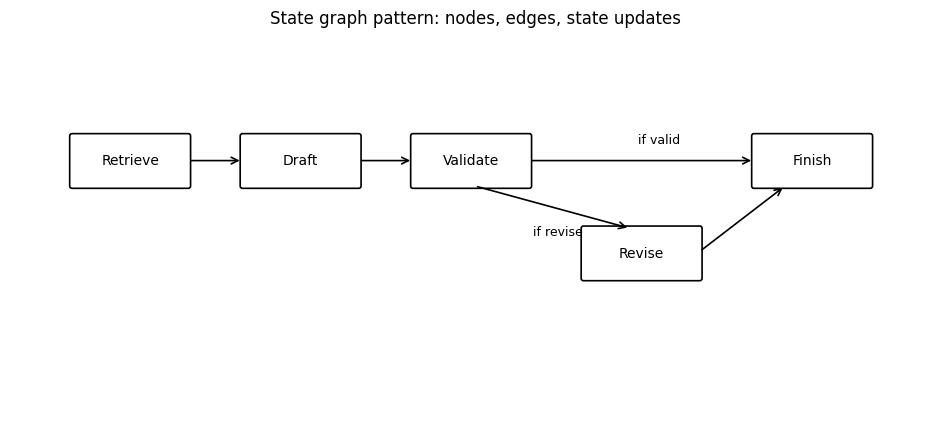

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.axis("off")
ax.set_xlim(0, 12)
ax.set_ylim(0, 5)

positions = {
    "retrieve": (0.8, 3.0),
    "draft": (3.0, 3.0),
    "validate": (5.2, 3.0),
    "revise": (7.4, 1.8),
    "finish": (9.6, 3.0),
}

for label, pos in positions.items():
    draw_box(ax, pos, label.title(), width=1.5, height=0.65)

draw_arrow(ax, (2.3, 3.33), (3.0, 3.33))
draw_arrow(ax, (4.5, 3.33), (5.2, 3.33))
draw_arrow(ax, (6.7, 3.33), (9.6, 3.33))
ax.text(8.1, 3.55, "if valid", fontsize=9)
draw_arrow(ax, (6.0, 3.0), (8.0, 2.45))
ax.text(6.75, 2.35, "if revise", fontsize=9)
draw_arrow(ax, (8.9, 2.15), (10.0, 3.0))

ax.set_title("State graph pattern: nodes, edges, state updates")
plt.show()

### Try it

Modify the graph so it includes a **human approval** node before finish.

Hints:

- Add `node_human_approval(state)`.
- Add a field like `state["approved"]`.
- Route to finish only if approved.
- Otherwise route to revise or stop safely.

In [ ]:
# Reference implementation: graph with a human approval node.

def node_human_approval(state: Dict[str, Any]) -> Dict[str, Any]:
    # In a real app, this could pause and wait for a human.
    # Here we simulate approval based on whether the draft includes an escalation note.
    state["approved"] = "human reviewer" in state["draft"].lower() or "escalate" in state["draft"].lower()
    state["trace"].append("human_approval")
    return state

graph_nodes_with_approval = {
    **graph_nodes,
    "human_approval": node_human_approval,
}

def run_state_graph_with_approval(initial_state: Dict[str, Any]) -> Dict[str, Any]:
    state = initial_state.copy()
    current_node = "retrieve"

    while current_node != "done":
        state = graph_nodes_with_approval[current_node](state)

        if current_node == "retrieve":
            current_node = "draft"
        elif current_node == "draft":
            current_node = "validate"
        elif current_node == "validate":
            current_node = "revise" if state["needs_revision"] else "human_approval"
        elif current_node == "revise":
            current_node = "human_approval"
        elif current_node == "human_approval":
            current_node = "finish" if state["approved"] else "done"
        elif current_node == "finish":
            current_node = "done"

    return state

run_state_graph_with_approval({
    "question": "Can a premium customer get a refund after 45 days?",
    "trace": [],
})

{'question': 'Can a premium customer get a refund after 45 days?',
 'trace': ['retrieve', 'draft', 'validate', 'human_approval', 'finish'],
 'retrieved_context': 'Context about: Can a premium customer get a refund after 45 days?. Policy says standard refunds are 30 days.',
 'draft': 'Based on context: Context about: Can a premium customer get a refund after 45 days?. Policy says standard refunds are 30 days. Recommendation: escalate if customer is premium or contract exception exists.',
 'needs_revision': False,
 'approved': True,
 'final': 'Based on context: Context about: Can a premium customer get a refund after 45 days?. Policy says standard refunds are 30 days. Recommendation: escalate if customer is premium or contract exception exists.'}

## 15. Faulty tool challenge

Real agentic workflows must handle tools that sometimes fail.

Below is a mock travel search tool that returns invalid output 30% of the time.

In [ ]:
TOKYO_TRAVEL_REQUEST = """
Plan a 3-day Tokyo trip for a vegetarian traveler.
Constraints:
- Budget under $900 excluding flights.
- Must include one quiet cultural activity.
- Avoid very crowded areas after 6 PM.
- Include one technology-themed stop.
- Traveler prefers walking but cannot walk more than 8 km/day.
"""

def mock_travel_api(query: str) -> str:
    """Return travel options, with occasional malformed JSON."""
    if random.random() < 0.30:
        return "{hotel: 'bad json', price: 140"

    response = {
        "hotel": "Ueno budget hotel",
        "price_per_night": 120,
        "currency": "USD",
        "nearby": ["Tokyo National Museum", "Ueno Park"],
        "crowd_level_evening": "medium",
    }
    return json.dumps(response)

for _ in range(5):
    print(mock_travel_api(TOKYO_TRAVEL_REQUEST))

{hotel: 'bad json', price: 140
{hotel: 'bad json', price: 140
{"hotel": "Ueno budget hotel", "price_per_night": 120, "currency": "USD", "nearby": ["Tokyo National Museum", "Ueno Park"], "crowd_level_evening": "medium"}
{"hotel": "Ueno budget hotel", "price_per_night": 120, "currency": "USD", "nearby": ["Tokyo National Museum", "Ueno Park"], "crowd_level_evening": "medium"}
{hotel: 'bad json', price: 140


In [ ]:
def safe_travel_search(query: str, max_attempts: int = 3) -> Dict[str, Any]:
    attempts = []

    for attempt in range(1, max_attempts + 1):
        raw = mock_travel_api(query)
        try:
            parsed = json.loads(raw)
            attempts.append({"attempt": attempt, "status": "ok", "raw": raw})
            return {
                "status": "success",
                "data": parsed,
                "attempts": attempts,
            }
        except json.JSONDecodeError:
            attempts.append({"attempt": attempt, "status": "json_error", "raw": raw})

    return {
        "status": "fallback",
        "data": {
            "message": "Could not fetch reliable travel API data. Use manual search or cached options."
        },
        "attempts": attempts,
    }

safe_travel_search(TOKYO_TRAVEL_REQUEST)

{'status': 'success',
 'data': {'hotel': 'Ueno budget hotel',
  'price_per_night': 120,
  'currency': 'USD',
  'nearby': ['Tokyo National Museum', 'Ueno Park'],
  'crowd_level_evening': 'medium'},
 'attempts': [{'attempt': 1,
   'status': 'json_error',
   'raw': "{hotel: 'bad json', price: 140"},
  {'attempt': 2,
   'status': 'ok',
   'raw': '{"hotel": "Ueno budget hotel", "price_per_night": 120, "currency": "USD", "nearby": ["Tokyo National Museum", "Ueno Park"], "crowd_level_evening": "medium"}'}]}

### Advanced extension

Build a mini agent for the Tokyo travel request:

1. Search for hotel data using `safe_travel_search`.
2. Validate the budget.
3. Draft a 3-day itinerary.
4. Reflect on whether it obeys all constraints.
5. If constraints are violated, revise.

In [ ]:
def draft_tokyo_itinerary(travel_data: Dict[str, Any], request: str) -> str:
    hotel = travel_data.get("hotel", "manual hotel search needed")
    nightly = travel_data.get("price_per_night", 150)

    return f"""
Draft itinerary:
- Hotel: {hotel} at approx. ${nightly}/night.
- Day 1: Ueno Park + Tokyo National Museum. Quiet cultural activity included.
- Day 2: Akihabara technology stop in the morning. Avoid crowded areas after 6 PM.
- Day 3: Yanaka walking route and vegetarian food stops.
Budget check: hotel approx. ${nightly * 3}; leaves room for transit, meals, and activities under $900.
Walking check: keep each day under 8 km by using metro between neighborhoods.
"""

def reflect_on_itinerary(itinerary: str) -> Dict[str, Any]:
    required = ["vegetarian", "quiet cultural", "technology", "under $900", "8 km"]
    missing = [item for item in required if item.lower() not in itinerary.lower()]
    return {
        "missing_constraints": missing,
        "recommendation": "revise" if missing else "ready",
    }

search_result = safe_travel_search(TOKYO_TRAVEL_REQUEST)
itinerary = draft_tokyo_itinerary(search_result["data"], TOKYO_TRAVEL_REQUEST)
reflection = reflect_on_itinerary(itinerary)

print(itinerary)
reflection


Draft itinerary:
- Hotel: Ueno budget hotel at approx. $120/night.
- Day 1: Ueno Park + Tokyo National Museum. Quiet cultural activity included.
- Day 2: Akihabara technology stop in the morning. Avoid crowded areas after 6 PM.
- Day 3: Yanaka walking route and vegetarian food stops.
Budget check: hotel approx. $360; leaves room for transit, meals, and activities under $900.
Walking check: keep each day under 8 km by using metro between neighborhoods.



{'missing_constraints': [], 'recommendation': 'ready'}

## LangGraph-style simulation

## Questions

1. “What did the graph make explicit that the crew did not?”  
   Expected answers:
   - State transitions.
   - Confidence thresholds.
   - Retry path.
   - Human-review path.
   - Stop condition.

2. “What did the graph make more rigid?”  
   Expected answers:
   - Flow must be designed upfront.
   - Less open-ended collaboration.
   - Requires more architectural thinking.

3. “How would you add durable state?”  
   Expected answer: Persist state after each node to a database/checkpoint store.

## Misconception to watch for

**Misconception:** “Graphs are only for deterministic code.”  
**Correction:** Graph nodes can call LLMs. The graph controls the allowed paths and state.


## 16. Final selection matrix

Use this matrix when deciding how to build an agentic system.

In [ ]:
selection_matrix = pd.DataFrame([
    {
        "Need": "Strict audit trail",
        "Best starting point": "State graph",
        "Why": "Explicit nodes, state, and decisions are easier to inspect.",
    },
    {
        "Need": "Creative collaboration",
        "Best starting point": "Role/task crew",
        "Why": "Multiple specialist perspectives can improve ideation.",
    },
    {
        "Need": "Connect local/private tools",
        "Best starting point": "MCP-style connector + orchestrator",
        "Why": "Keeps data/tool access controlled while allowing model use.",
    },
    {
        "Need": "Safety validation",
        "Best starting point": "Lifecycle hooks",
        "Why": "Deterministic checks block unsafe or invalid actions.",
    },
    {
        "Need": "Fast prototype",
        "Best starting point": "Lightweight SDK or no-code workflow",
        "Why": "Lower setup friction and easier first demo.",
    },
    {
        "Need": "Production multi-step process",
        "Best starting point": "State graph + tracing",
        "Why": "Debuggability and recovery matter as complexity grows.",
    },
])

selection_matrix

,Need,Best starting point,Why
0,Strict audit trail,State graph,"Explicit nodes, state, and decisions are easier to inspect."
1,Creative collaboration,Role/task crew,Multiple specialist perspectives can improve ideation.
2,Connect local/private tools,MCP-style connector + orchestrator,Keeps data/tool access controlled while allowing model use.
3,Safety validation,Lifecycle hooks,Deterministic checks block unsafe or invalid actions.
4,Fast prototype,Lightweight SDK or no-code workflow,Lower setup friction and easier first demo.
5,Production multi-step process,State graph + tracing,Debuggability and recovery matter as complexity grows.


### Your domain decision

Pick one workflow from your domain and complete this template.

| Question | Your answer |
|---|---|
| What does the agent observe/read? |  |
| What decisions must it make? |  |
| What tools/actions must it use? |  |
| What can go wrong? |  |
| Does it need memory? |  |
| Does it need human approval? |  |
| Which orchestration style would you start with? |  |
| What would you log for observability? |  |

# Pro Lab — Optional: local log reader as an MCP-style mental model

This is **not** a full MCP server. It is a simple local tool that reads from a local data source. The point is to understand the principle:

> Keep the data/tool local, expose a clean interface, and let the orchestrator decide when to call it.

In [ ]:
# Create a small local "log file" in memory.
server_logs = [
    "2026-05-01 09:00 INFO service started",
    "2026-05-01 09:05 WARN latency above threshold route=/checkout p95=1200ms",
    "2026-05-01 09:06 ERROR payment gateway timeout order_id=1002",
    "2026-05-01 09:07 INFO retry succeeded order_id=1002",
    "2026-05-01 09:10 ERROR database connection pool exhausted",
]

def local_log_search(keyword: str) -> List[str]:
    return [line for line in server_logs if keyword.lower() in line.lower()]

def incident_triage_agent(issue: str) -> Dict[str, Any]:
    if "payment" in issue.lower():
        logs = local_log_search("payment")
    elif "database" in issue.lower() or "db" in issue.lower():
        logs = local_log_search("database")
    else:
        logs = local_log_search("ERROR")

    severity = "high" if any("ERROR" in line for line in logs) else "medium" if logs else "low"

    return {
        "issue": issue,
        "logs_found": logs,
        "severity": severity,
        "next_action": "page on-call" if severity == "high" else "monitor",
    }

incident_triage_agent("Payment checkout is failing for users.")

{'issue': 'Payment checkout is failing for users.',
 'logs_found': ['2026-05-01 09:06 ERROR payment gateway timeout order_id=1002'],
 'severity': 'high',
 'next_action': 'page on-call'}

### Pro Lab extensions

1. Add a second local tool: `lookup_runbook(service_name)`.
2. Add a state graph:
   - search logs
   - classify severity
   - lookup runbook
   - draft incident message
   - require human approval before paging
3. Add tracing for each step.

# Assessment: check your understanding

Answer these before closing the notebook.

1. Why is a retry loop orchestration logic, not model intelligence?
2. What is the difference between a tool registry and an executor?
3. What is stored in state?
4. When would you prefer a state graph over a role/task crew?
5. Why does observability matter more in agents than in single-shot prompts?
6. What is the “agent tax”?
7. What failure types should you distinguish when debugging an agent?

In [ ]:
assessment_answer_key = {
    "1": "The retry loop is deterministic control: parse, validate, retry, stop, or escalate.",
    "2": "The registry lists available tools; the executor actually calls the selected tool and handles result/errors.",
    "3": "State stores facts, messages, tool outputs, decisions, counters, approvals, and workflow progress.",
    "4": "Use a state graph when you need auditability, explicit branches, approvals, recovery, or compliance.",
    "5": "Agents have multiple steps and tools; traces reveal where the workflow failed or drifted.",
    "6": "The added cost, latency, and debugging complexity from multiple calls, tool use, retries, and validation.",
    "7": "Logic/planning failures, tool/API failures, and data/context failures.",
}

assessment_answer_key

{'1': 'The retry loop is deterministic control: parse, validate, retry, stop, or escalate.',
 '2': 'The registry lists available tools; the executor actually calls the selected tool and handles result/errors.',
 '3': 'State stores facts, messages, tool outputs, decisions, counters, approvals, and workflow progress.',
 '4': 'Use a state graph when you need auditability, explicit branches, approvals, recovery, or compliance.',
 '5': 'Agents have multiple steps and tools; traces reveal where the workflow failed or drifted.',
 '6': 'The added cost, latency, and debugging complexity from multiple calls, tool use, retries, and validation.',
 '7': 'Logic/planning failures, tool/API failures, and data/context failures.'}

# Homework / follow-up

Choose one agentic workflow from your domain and design its first version.

Submit:

1. **Goal:** What should the agent accomplish?
2. **Observe:** What information does it read?
3. **Think:** What decision or classification does it make?
4. **Act:** What tool/action does it take?
5. **State:** What must it remember?
6. **Failure handling:** What can go wrong and how will it recover?
7. **Framework choice:** Raw Python, state graph, role/task crew, no-code workflow, or MCP-style tool connector?
8. **Trace plan:** What will you log?

Optional build challenge:

- Implement a raw Python prototype using the patterns in this notebook.
- Add at least one tool, one state field, one validation rule, and one trace table.

# Notebook recap

You have now built the core ideas behind agent orchestration without relying on a full framework:

- Tool routing
- Retry and validation
- State management
- Reflection/quality gates
- Role/task orchestration
- State-machine orchestration
- Observability
- Framework selection

When you later use libraries such as LangGraph, CrewAI, or agent SDKs, remember:

> The framework is not the magic. The orchestration design is the magic.

# Recap Summary



1. Week 2 was about retrieval and RAG.
2. Day 1 showed that real tasks need loops, state, tools, retries, and validation.
3. Day 2 showed that frameworks are not magic; they package orchestration choices.
4. LangGraph-style systems emphasize explicit state and control.
5. CrewAI-style systems emphasize role-based collaboration.
6. MCP connects agents to tools and data; it does not replace orchestration.
7. Observability is essential because agent failures are multi-step failures.
8. The best architecture is often hybrid: deterministic gates around probabilistic reasoning.

 “Your Week 2 RAG app could answer from knowledge. Your Week 3 agent can manage work around knowledge.”